# Bonus

🎯 84 feature’dan oluşan tam `ML_Houses_dataset.csv` dataset’iyle [buradan ulaşarak](https://d32aokrjazspmn.cloudfront.net/materials/ML_Houses_dataset.csv) serbestçe çalışabilirsiniz!

- Feature’ları inceleyin
- Uygun şekilde preprocess edin ve encode edin
- Feature engineering için beyin fırtınası yapın
- Bunları modelinize ekleyin
- Feature selection uygulayın

👇 Dosyayı yerel olarak `data` klasörüne kaydedin ve buradan içe aktarın.

ℹ️ Dataset’in açıklamasına mutlaka [buradan](https://drive.google.com/file/d/1qLxeQXufW_-KHOckpUweLPhitzjnP7H3/view?usp=sharing) referans verin.

In [23]:
# 💻 Gerekli kütüphaneler
import pandas as pd
import numpy as np

# 🏠 Dataseti yükleme
data_path = r"C:\Users\meaki\AppData\Local\GitHubDesktop\app-3.5.4\S16D2-S-Data-houses_preparation\ML_Houses_dataset.csv"
df = pd.read_csv(data_path)

# 🔎 İlk bakış
print("Dataset boyutu:", df.shape)
print("\nİlk 5 satır:\n", df.head())
print("\nDeğişken tipleri:\n", df.dtypes)
print("\nEksik değerler:\n", df.isnull().sum().sort_values(ascending=False).head(20))

Dataset boyutu: (1760, 85)

İlk 5 satır:
    Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  YrSold  SaleType  SaleCo

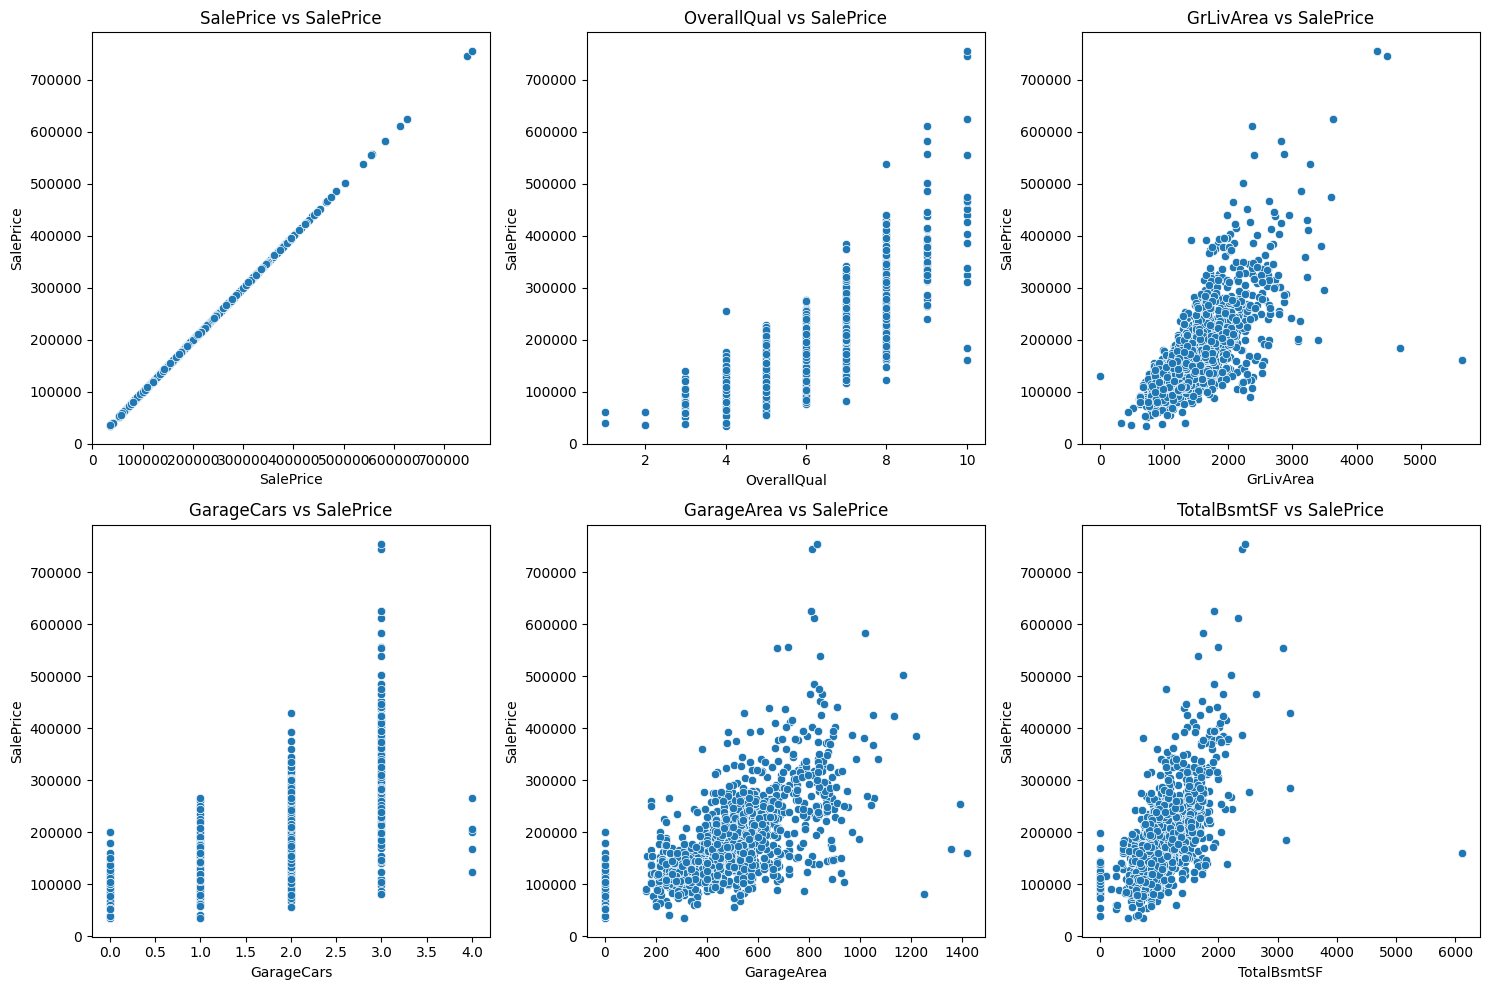

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sayısal sütunları seç
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
num_cols.remove('Id')  # Id target değil, drop
num_cols.remove('SalePrice')  # Target

# Feature-target scatter plot (ilk 6 önemli feature için)
top_features = corr_matrix['SalePrice'].abs().sort_values(ascending=False).index[1:7]

plt.figure(figsize=(15,10))
for i, col in enumerate(top_features):
    plt.subplot(2,3,i+1)
    sns.scatterplot(data=df, x=col, y='SalePrice')
    plt.title(f"{col} vs SalePrice")
plt.tight_layout()
plt.show()

In [25]:
# Kategorik sütunları seç
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

# Her kategorik feature için:
for col in cat_cols:
    print(f"Feature: {col}")
    print(f"Unique values ({df[col].nunique()}): {df[col].unique()}")
    print(f"Missing values: {df[col].isnull().sum()}")
    print("-"*50)

Feature: MSZoning
Unique values (5): ['RL' 'RM' 'C (all)' 'FV' 'RH']
Missing values: 0
--------------------------------------------------
Feature: Street
Unique values (2): ['Pave' 'Grvl']
Missing values: 0
--------------------------------------------------
Feature: Alley
Unique values (2): [nan 'Grvl' 'Pave']
Missing values: 1648
--------------------------------------------------
Feature: LotShape
Unique values (4): ['Reg' 'IR1' 'IR2' 'IR3']
Missing values: 0
--------------------------------------------------
Feature: LandContour
Unique values (4): ['Lvl' 'Bnk' 'Low' 'HLS']
Missing values: 0
--------------------------------------------------
Feature: Utilities
Unique values (2): ['AllPub' 'NoSeWa']
Missing values: 0
--------------------------------------------------
Feature: LotConfig
Unique values (5): ['Inside' 'FR2' 'Corner' 'CulDSac' 'FR3']
Missing values: 0
--------------------------------------------------
Feature: LandSlope
Unique values (3): ['Gtl' 'Mod' 'Sev']
Missing values:

In [26]:
df["HasPool"] = df["PoolQC"].notnull().astype(int)
df["HasFence"] = df["Fence"].notnull().astype(int)
df["HasAlley"] = df["Alley"].notnull().astype(int)
df["HasMisc"] = df["MiscFeature"].notnull().astype(int)

In [27]:
quality_map = {
    "Ex":5,
    "Gd":4,
    "TA":3,
    "Fa":2,
    "Po":1
}

In [28]:
for col in cat_cols:
    print("\n", "="*40)
    print("Feature:", col)
    print(df.groupby(col)["SalePrice"].median().sort_values(ascending=False))


Feature: MSZoning
MSZoning
FV         207500.0
RL         174000.0
RH         140000.0
RM         122000.0
C (all)     74700.0
Name: SalePrice, dtype: float64

Feature: Street
Street
Pave    163990.0
Grvl    110000.0
Name: SalePrice, dtype: float64

Feature: Alley
Alley
Pave    168300.0
Grvl    119000.0
Name: SalePrice, dtype: float64

Feature: LotShape
LotShape
IR2    212000.0
IR1    190000.0
IR3    186570.0
Reg    147000.0
Name: SalePrice, dtype: float64

Feature: LandContour
LandContour
HLS    220000.0
Low    188750.0
Lvl    164000.0
Bnk    140000.0
Name: SalePrice, dtype: float64

Feature: Utilities
Utilities
AllPub    163500.0
NoSeWa    137500.0
Name: SalePrice, dtype: float64

Feature: LotConfig
LotConfig
CulDSac    197900.0
FR3        195450.0
FR2        164500.0
Corner     163250.0
Inside     160000.0
Name: SalePrice, dtype: float64

Feature: LandSlope
LandSlope
Sev    182500.0
Mod    172000.0
Gtl    162900.0
Name: SalePrice, dtype: float64

Feature: Neighborhood
Neighborhood


In [29]:
import numpy as np
import pandas as pd

df = df.copy()

# -----------------------------
# 1️⃣ ORDINAL MAPPINGS
# -----------------------------

qual_map = {
    "Po": 1,
    "Fa": 2,
    "TA": 3,
    "Gd": 4,
    "Ex": 5
}

bsmt_fin_map = {
    "Unf": 1,
    "LwQ": 2,
    "Rec": 3,
    "BLQ": 4,
    "ALQ": 5,
    "GLQ": 6
}

lotshape_map = {
    "Reg": 1,
    "IR1": 2,
    "IR2": 3,
    "IR3": 4
}

landslope_map = {
    "Sev": 1,
    "Mod": 2,
    "Gtl": 3
}

functional_map = {
    "Sev": 1,
    "Maj2": 2,
    "Maj1": 3,
    "Mod": 4,
    "Min2": 5,
    "Min1": 6,
    "Typ": 7
}

# -----------------------------
# 2️⃣ APPLY ORDINAL ENCODING
# -----------------------------

ordinal_cols = [
    "ExterQual", "ExterCond",
    "BsmtQual", "BsmtCond",
    "HeatingQC",
    "KitchenQual",
    "GarageQual", "GarageCond",
    "FireplaceQu"
]

for col in ordinal_cols:
    df[col] = df[col].map(qual_map)

df["BsmtFinType1"] = df["BsmtFinType1"].map(bsmt_fin_map)
df["BsmtFinType2"] = df["BsmtFinType2"].map(bsmt_fin_map)
df["LotShape"] = df["LotShape"].map(lotshape_map)
df["LandSlope"] = df["LandSlope"].map(landslope_map)
df["Functional"] = df["Functional"].map(functional_map)

# -----------------------------
# 3️⃣ MISSING HANDLING (STRUCTURAL)
# -----------------------------

# Basement yoksa 0
bsmt_cols = ["BsmtQual","BsmtCond","BsmtFinType1","BsmtFinType2"]
for col in bsmt_cols:
    df[col] = df[col].fillna(0)

# Garage yoksa 0
garage_cols = ["GarageQual","GarageCond"]
for col in garage_cols:
    df[col] = df[col].fillna(0)

# Fireplace yoksa 0
df["FireplaceQu"] = df["FireplaceQu"].fillna(0)

# Electrical tek missing vardı
df["Electrical"] = df["Electrical"].fillna(df["Electrical"].mode()[0])

# -----------------------------
# 4️⃣ BINARY FEATURES
# -----------------------------

df["HasBasement"] = (df["TotalBsmtSF"] > 0).astype(int)
df["HasGarage"] = (df["GarageCars"] > 0).astype(int)
df["HasFireplace"] = (df["Fireplaces"] > 0).astype(int)
df["HasPool"] = (df["PoolArea"] > 0).astype(int)
df["HasFence"] = df["Fence"].notnull().astype(int)

# -----------------------------
# 5️⃣ NEW ENGINEERED FEATURES
# -----------------------------

df["TotalBath"] = (
    df["FullBath"] +
    0.5 * df["HalfBath"] +
    df["BsmtFullBath"] +
    0.5 * df["BsmtHalfBath"]
)

df["HouseAge"] = df["YrSold"] - df["YearBuilt"]
df["RemodAge"] = df["YrSold"] - df["YearRemodAdd"]

df["TotalQualScore"] = (
    df["OverallQual"] +
    df["ExterQual"] +
    df["KitchenQual"] +
    df["BsmtQual"] +
    df["GarageQual"]
)



In [30]:
from sklearn.model_selection import train_test_split

df_model = df.copy()

# -----------------------------
# 1️⃣ DROP USELESS / HIGH MISSING
# -----------------------------

drop_cols = [
    "Id",
    "Utilities",
    "WallMat",
    "PoolQC",
    "MiscFeature"
]

df_model = df_model.drop(columns=[c for c in drop_cols if c in df_model.columns])

# -----------------------------
# 2️⃣ ONE HOT ENCODE
# -----------------------------

categorical_cols = df_model.select_dtypes(include="object").columns.tolist()

df_model = pd.get_dummies(df_model, columns=categorical_cols, drop_first=True)

# -----------------------------
# 3️⃣ TARGET LOG TRANSFORM
# -----------------------------

y = np.log1p(df_model["SalePrice"])
X = df_model.drop("SalePrice", axis=1)

# -----------------------------
# 4️⃣ TRAIN TEST SPLIT
# -----------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("Toplam feature sayısı:", X.shape[1])

X_train shape: (1408, 214)
X_test shape: (352, 214)
Toplam feature sayısı: 214


In [32]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

df_model = df.copy()

# -----------------------------
# 1️⃣ OneHot encode
# -----------------------------
df_model = pd.get_dummies(df_model, drop_first=True)

# -----------------------------
# 2️⃣ Target & Features
# -----------------------------
y = np.log1p(df_model["SalePrice"])
X = df_model.drop("SalePrice", axis=1)

# -----------------------------
# 3️⃣ GARANTİ NaN TEMİZLİĞİ
# -----------------------------
X = X.fillna(0)

# Kontrol
print("Kalan NaN sayısı:", X.isnull().sum().sum())

# -----------------------------
# 4️⃣ Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------------
# 5️⃣ Linear Regression
# -----------------------------
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_train = lr.predict(X_train)
y_pred_test = lr.predict(X_test)

rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))

print("\nLinear Regression Results")
print("Train RMSE:", rmse_train)
print("Test RMSE:", rmse_test)

Kalan NaN sayısı: 0

Linear Regression Results
Train RMSE: 0.08471772277824922
Test RMSE: 0.16560784617424215
